In [1]:
import torch
import torch.nn as nn
from torchvision.transforms import v2
from torch.utils.data import DataLoader
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from pathlib import Path
import numpy as np

from myViT import VisionTransformer
from ViTTrainer import ViT_train
from view_preds import show_prediction_side_by_side
from sched_optim import build_optimizer_and_scheduler
from plot_losses import plot_losses
from build_dataloaders_ViT import build_train_dl
from sanity_test_overfit import run_sanity_suite
import build_dataloaders_ViT

import sys
# sys.path.append("..")

sys.path.append(str(Path.cwd().parent / "self-driving-car"))
from v2.CarImageClass import ImageClass, make_train_test_split
# from v2.training_files.CosSched import build_optimizer_and_scheduler
from v2.training_files.save_load_ckpt import load_checkpoint
# from v2.training_files.plot_losses import plot_losses
from v2.training_files.CondIoUCrop import ConditionalIoUCrop


device = "cuda" if torch.cuda.is_available() else "cpu"

# set file path
# desktop or laptop
machine = 'desktop'

# Setup path to data folder
if machine == 'laptop':
    folder_path = Path(r"C:\self-driving-car\data")
else:
    folder_path = Path(r"C:\Udacity_car_data\data")

train_path = folder_path / "train"
test_path = folder_path / "test"


def collate_detection(batch):
    # batch: list of (img, target) tuples
    imgs  = [img for img, _ in batch]
    tgts  = [tgt for _, tgt in batch]
    return torch.stack(imgs, dim=0), tgts

In [2]:
sanity_runs = run_sanity_suite(
    train_path=train_path,
    num_images=9,
    file_pct=0.0005,
    one_image_steps=2_000,
    all_image_steps=10_000,
    eval_every=100,
    learning_rate=3e-4,
    seed=724,
    device=device,
    grad_clip_val=0.1,
)

Frozen 9 images; object counts: [8, 2, 5, 12, 6, 0, 11, 7, 9]

ONE-IMAGE SANITY TEST: 1 image(s), one optimizer step per iteration, lr=0.0003, grad_clip_val=0.1
step=    1  loss=10.3018  CE=3.6499  L1=0.5344  GIoU=1.9899  mAP@.50=0.0000  pre-clip |g|=39.8140  post-clip |g|=0.1000
step=  100  loss=5.7810  CE=1.1640  L1=0.1125  GIoU=2.0273  mAP@.50=0.0000  pre-clip |g|=952.6038  post-clip |g|=0.1000
step=  200  loss=4.7133  CE=0.6314  L1=0.0903  GIoU=1.8153  mAP@.50=0.0000  pre-clip |g|=257.3047  post-clip |g|=0.1000
step=  300  loss=4.2275  CE=0.3990  L1=0.0890  GIoU=1.6917  mAP@.50=0.0000  pre-clip |g|=144.5207  post-clip |g|=0.1000
step=  400  loss=4.0533  CE=0.2622  L1=0.0930  GIoU=1.6631  mAP@.50=0.0000  pre-clip |g|=83.2036  post-clip |g|=0.1000
step=  500  loss=3.9714  CE=0.1923  L1=0.0899  GIoU=1.6649  mAP@.50=0.0000  pre-clip |g|=149.5333  post-clip |g|=0.1000
step=  600  loss=3.9054  CE=0.1566  L1=0.0901  GIoU=1.6493  mAP@.50=0.0000  pre-clip |g|=137.4698  post-clip |g|=0.1000


In [3]:
for name, result in sanity_runs.items():
    best = max(result.history, key=lambda row: row["map50"])
    final = result.history[-1]

    print(f"\n{name}")
    print("best:", best)
    print("final:", final)


one_image
best: {'step': 1.0, 'loss': 10.301765441894531, 'ce': 3.649878978729248, 'l1': 0.534423828125, 'giou': 1.9898834228515625, 'map50': 0.0, 'pre_clip_grad_norm': 39.814029693603516, 'post_clip_grad_norm': 0.10000000149011612, 'lr': 0.00029999981556180566}
final: {'step': 2000.0, 'loss': 3.642951011657715, 'ce': 0.06273818016052246, 'l1': 0.0862639769911766, 'giou': 1.574446439743042, 'map50': 0.0, 'pre_clip_grad_norm': 677.9669799804688, 'post_clip_grad_norm': 0.10000000149011612, 'lr': 1e-06}

all_images
best: {'step': 7900.0, 'loss': 0.8088670372962952, 'ce': 0.06057062745094299, 'l1': 0.02382020279765129, 'giou': 0.3145976960659027, 'map50': 0.8887509703636169, 'pre_clip_grad_norm': 440.3063049316406, 'post_clip_grad_norm': 0.10000000149011612, 'lr': 3.237182564983403e-05}
final: {'step': 10000.0, 'loss': 0.7101554870605469, 'ce': 0.057093940675258636, 'l1': 0.022721067070961, 'giou': 0.2697281241416931, 'map50': 0.8884833455085754, 'pre_clip_grad_norm': 393.93646240234375, 

In [4]:
# grad clip 1.0

sanity_runs = run_sanity_suite(
    train_path=train_path,
    num_images=9,
    file_pct=0.0005,
    one_image_steps=2_000,
    all_image_steps=10_000,
    eval_every=100,
    learning_rate=3e-4,
    seed=724,
    device=device,
    grad_clip_val=1.0,
)

for name, result in sanity_runs.items():
    best = max(result.history, key=lambda row: row["map50"])
    final = result.history[-1]

    print(f"\n{name}")
    print("best:", best)
    print("final:", final)

Frozen 9 images; object counts: [8, 2, 5, 12, 6, 0, 11, 7, 9]

ONE-IMAGE SANITY TEST: 1 image(s), one optimizer step per iteration, lr=0.0003, grad_clip_val=1
step=    1  loss=10.3018  CE=3.6499  L1=0.5344  GIoU=1.9899  mAP@.50=0.0000  pre-clip |g|=39.8140  post-clip |g|=1.0000
step=  100  loss=5.5490  CE=1.1883  L1=0.1136  GIoU=1.8963  mAP@.50=0.0000  pre-clip |g|=176.5038  post-clip |g|=1.0000
step=  200  loss=4.8488  CE=0.7467  L1=0.0920  GIoU=1.8210  mAP@.50=0.0000  pre-clip |g|=328.2294  post-clip |g|=1.0000
step=  300  loss=4.3542  CE=0.4286  L1=0.0861  GIoU=1.7475  mAP@.50=0.0000  pre-clip |g|=141.9705  post-clip |g|=1.0000
step=  400  loss=4.1036  CE=0.2697  L1=0.0987  GIoU=1.6702  mAP@.50=0.0000  pre-clip |g|=144.0566  post-clip |g|=1.0000
step=  500  loss=4.0551  CE=0.1989  L1=0.0871  GIoU=1.7103  mAP@.50=0.0000  pre-clip |g|=154.3117  post-clip |g|=1.0000
step=  600  loss=3.8658  CE=0.1491  L1=0.0890  GIoU=1.6358  mAP@.50=0.0000  pre-clip |g|=151.7457  post-clip |g|=1.0000
s

In [5]:
# grad clip 10.0

sanity_runs = run_sanity_suite(
    train_path=train_path,
    num_images=9,
    file_pct=0.0005,
    one_image_steps=2_000,
    all_image_steps=10_000,
    eval_every=100,
    learning_rate=3e-4,
    seed=724,
    device=device,
    grad_clip_val=10.0,
)

for name, result in sanity_runs.items():
    best = max(result.history, key=lambda row: row["map50"])
    final = result.history[-1]

    print(f"\n{name}")
    print("best:", best)
    print("final:", final)

Frozen 9 images; object counts: [8, 2, 5, 12, 6, 0, 11, 7, 9]

ONE-IMAGE SANITY TEST: 1 image(s), one optimizer step per iteration, lr=0.0003, grad_clip_val=10
step=    1  loss=10.3018  CE=3.6499  L1=0.5344  GIoU=1.9899  mAP@.50=0.0000  pre-clip |g|=39.8140  post-clip |g|=10.0000
step=  100  loss=5.2443  CE=1.3404  L1=0.1048  GIoU=1.6899  mAP@.50=0.0000  pre-clip |g|=130.4212  post-clip |g|=10.0000
step=  200  loss=4.8390  CE=0.8575  L1=0.1018  GIoU=1.7362  mAP@.50=0.0000  pre-clip |g|=727.2843  post-clip |g|=10.0000
step=  300  loss=4.3091  CE=0.4323  L1=0.0968  GIoU=1.6964  mAP@.50=0.0000  pre-clip |g|=449.7638  post-clip |g|=10.0000
step=  400  loss=4.0063  CE=0.1735  L1=0.0914  GIoU=1.6879  mAP@.50=0.0000  pre-clip |g|=174.5227  post-clip |g|=10.0000
step=  500  loss=3.9076  CE=0.1184  L1=0.0942  GIoU=1.6590  mAP@.50=0.0000  pre-clip |g|=65.7884  post-clip |g|=10.0000
step=  600  loss=3.8888  CE=0.0798  L1=0.0944  GIoU=1.6684  mAP@.50=0.0000  pre-clip |g|=139.0366  post-clip |g|=10

In [6]:
# grad clip 1.0

sanity_runs = run_sanity_suite(
    train_path=train_path,
    num_images=9,
    file_pct=0.0005,
    one_image_steps=4_000,
    all_image_steps=0,
    eval_every=100,
    learning_rate=3e-4,
    seed=724,
    device=device,
    grad_clip_val=1.0,
)

for name, result in sanity_runs.items():
    best = max(result.history, key=lambda row: row["map50"])
    final = result.history[-1]

    print(f"\n{name}")
    print("best:", best)
    print("final:", final)

Frozen 9 images; object counts: [8, 2, 5, 12, 6, 0, 11, 7, 9]

ONE-IMAGE SANITY TEST: 1 image(s), one optimizer step per iteration, lr=0.0003, grad_clip_val=1
step=    1  loss=10.3018  CE=3.6499  L1=0.5344  GIoU=1.9899  mAP@.50=0.0000  pre-clip |g|=39.8140  post-clip |g|=1.0000
step=  100  loss=5.6140  CE=0.9310  L1=0.1757  GIoU=1.9024  mAP@.50=0.0000  pre-clip |g|=669.4363  post-clip |g|=1.0000
step=  200  loss=4.6122  CE=0.6067  L1=0.0898  GIoU=1.7781  mAP@.50=0.0000  pre-clip |g|=137.6159  post-clip |g|=1.0000
step=  300  loss=4.2635  CE=0.4165  L1=0.0948  GIoU=1.6865  mAP@.50=0.0000  pre-clip |g|=98.1801  post-clip |g|=1.0000
step=  400  loss=4.1074  CE=0.2901  L1=0.0945  GIoU=1.6724  mAP@.50=0.0000  pre-clip |g|=156.5704  post-clip |g|=1.0000
step=  500  loss=4.1966  CE=0.2234  L1=0.0962  GIoU=1.7461  mAP@.50=0.0000  pre-clip |g|=325.1472  post-clip |g|=1.0000
step=  600  loss=3.9566  CE=0.1325  L1=0.0927  GIoU=1.6805  mAP@.50=0.0000  pre-clip |g|=157.3759  post-clip |g|=1.0000
st

ValueError: max() iterable argument is empty

In [12]:
# ~22.5 million parameters
ViTmodel = VisionTransformer(class_to_idx_dict={'biker': 0, 'car': 1, 'pedestrian': 2, 'trafficLight': 3, 'truck': 4},
                             img_size=300,
                             patch_H=20,
                             patch_W=15,
                             in_channels=3,
                             embed_dim=256,
                             num_layers=12,
                             num_heads=4,
                             dim_feedforward=256*4,
                             dropout=0.1,
                             num_queries=50).to(device)



train_dataloader, val_dataloader = build_train_dl(train_path=train_path,
                                                  batch_size=64,
                                                  num_workers=4,
                                                  prefetch_factor=2)

optimizer, scheduler = build_optimizer_and_scheduler(model=ViTmodel,
                                                     train_dataloader=train_dataloader,
                                                     max_epochs=250,
                                                     warmup_epochs=5,
                                                     base_lr=1e-4,
                                                     min_lr=1e-7,
                                                     weight_decay=0.005)

scaler = torch.amp.GradScaler("cuda", enabled=(device == "cuda"))

resume_path = Path("C:/Users/eblac/Documents/GitHub/myTransformer/saved_models/last.ckpt")
# Path.home() / "repos" / "automotive-ssd-object-detection" / "v2" / "saved_models" / "last.ckpt"
if resume_path.exists():
    start_epoch, best_map, loss_dict = load_checkpoint(
        resume_path, ViTmodel, optimizer=optimizer, scheduler=scheduler,
        scaler=scaler, map_location="cpu"  # safe load, then move to device
    )
    ViTmodel.to(device)
else:
    start_epoch, best_map, loss_dict = 0, None, None

results = ViT_train(model=ViTmodel,
                    train_dataloader=train_dataloader,
                    test_dataloader=val_dataloader,
                    optimizer=optimizer,
                    lambda_CE=1.0,
                    lambda_L1=5.0,
                    lambda_GIoU=2.0,
                    lambda_CE_HM=1.0,
                    lambda_L1_HM=5.0,
                    lambda_GIoU_HM=2.0,
                    scheduler=scheduler,
                    scaler=scaler,
                    sched_step_w_opt=True,
                    epochs=1,
                    early_stopping_rounds=None,
                    device=device,
                    save_model=False,
                    save_best_model=False,
                    epoch_save_interval=None,
                    SAVE_DIR=Path("C:/Users/eblac/Documents/GitHub/myTransformer/saved_models"),
                    timing=False,
                    past_train_dict=loss_dict,
                    compute_mAP_train=True,
                    compute_mAP_test=False,
                    include_test_step=False,
                    bg_weight=0.05)

  0%|          | 0/1 [00:00<?, ?it/s]

Epoch: 131  |  mAP: 0.0020  |  Train L1 loss: 0.0352  |  Train CE loss: 0.8190  |  Train GIoU loss: 0.7433  |  Test L1 loss: 0.0000  |  Test CE loss: 0.0000  |  Test GIoU loss: 0.0000  


In [3]:
pred_class_logits, _ = ViTmodel(train_data[1][0].unsqueeze(0).to(device))

probs = pred_class_logits.softmax(-1)

matched_mask = torch.zeros(
    pred_class_logits.shape[:2],
    dtype=torch.bool,
    device=pred_class_logits.device
)

# set matched query positions True ...

print(
    "unmatched mean no-object probability:",
    probs[..., -1][~matched_mask].mean().item()
)

NameError: name 'train_data' is not defined

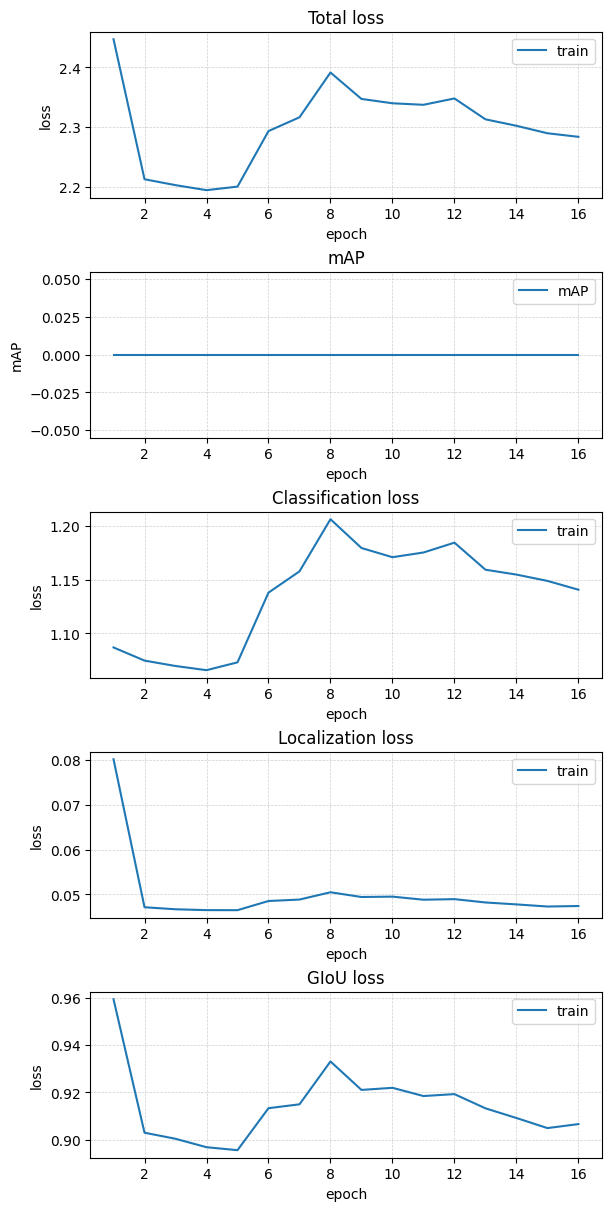

In [ ]:
plot_train_losses(results, figsize=(6, 12))

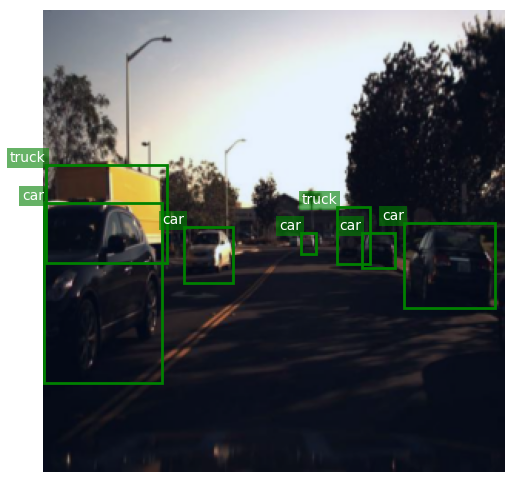

In [ ]:
train_data.show_with_box(4, label=True);

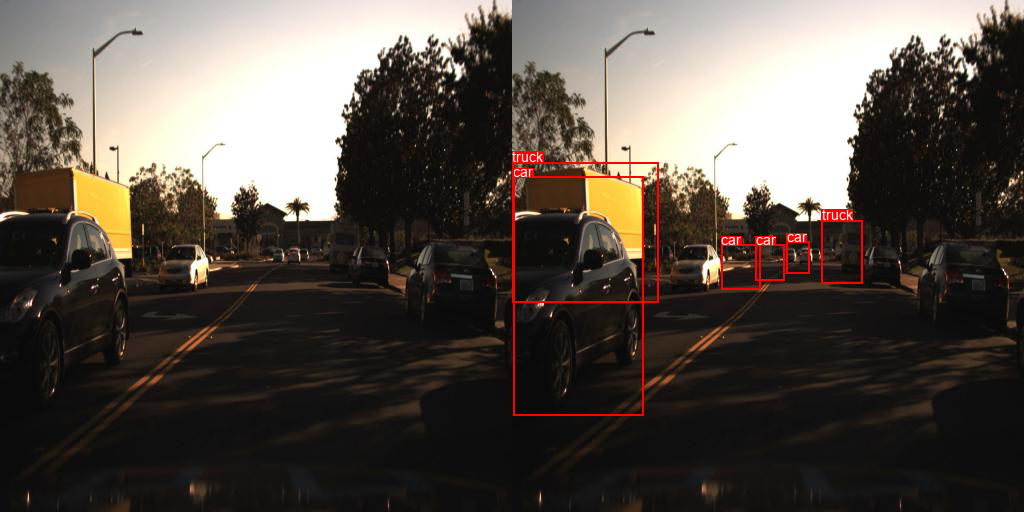

In [ ]:
show_prediction_side_by_side(model=ViTmodel,
                             image_path=train_data.paths[4],
                             #image_path=r"C:\Udacity_car_data\data\test\1478020225692825294_jpg.rf.56eb69377e7d753621a360ec59206e2f.jpg",
                             pil_img=None,
                             conf_thresh=0.95)

In [5]:
ViTmodel = VisionTransformer(class_to_idx_dict={'biker': 0, 'car': 1, 'pedestrian': 2, 'trafficLight': 3, 'truck': 4},
                             img_size=300,
                             patch_H=15,
                             patch_W=10,
                             in_channels=3,
                             embed_dim=256,
                             num_layers=6,
                             num_heads=4,
                             dim_feedforward=256*4,
                             dropout=0.0,
                             num_queries=50).to(device)

total_params = sum(p.numel() for p in ViTmodel.parameters())

print(f"Total parameters: {total_params:,}")

Total parameters: 11,322,634


In [ ]:
fiddle = ImageClass(targ_dir=train_path, transform=None, file_pct=1, rand_seed=724, include_area=False)

In [ ]:
len(fiddle)

19863

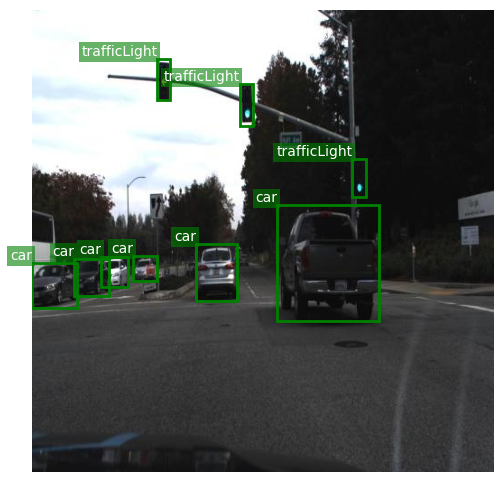

In [ ]:
import numpy as np

rng = np.random.default_rng()
random_int = rng.integers(low=0, high=19863)

fiddle.show_with_box(random_int, label=True);

In [ ]:
random_int

np.int64(11762)

In [ ]:
random_int

np.int64(15814)

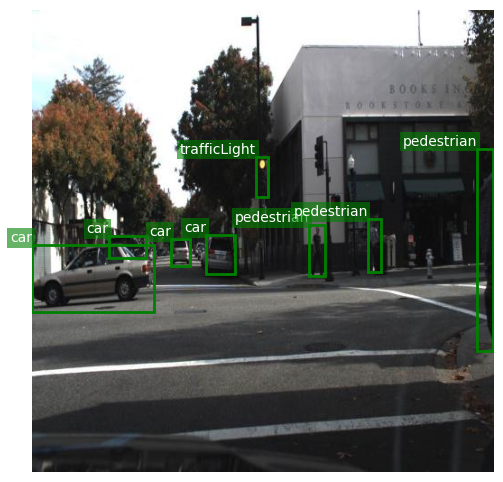

In [ ]:
random_int = rng.integers(low=0, high=19863)

fiddle.show_with_box(random_int, label=True);

In [2]:
# ~11.3 million parameters
ViTmodel = VisionTransformer(class_to_idx_dict={'biker': 0, 'car': 1, 'pedestrian': 2, 'trafficLight': 3, 'truck': 4},
                             img_size=300,
                             patch_H=15,
                             patch_W=10,
                             in_channels=3,
                             embed_dim=256,
                             num_layers=6,
                             num_heads=4,
                             dim_feedforward=256*4,
                             dropout=0.1,
                             num_queries=50).to(device)

resume_path = Path("C:/Users/eblac/Documents/GitHub/myTransformer/saved_models/best.ckpt")
if resume_path.exists():
    start_epoch, best_map, loss_dict = load_checkpoint(
        resume_path, ViTmodel, optimizer=None, scheduler=None,
        scaler=None, map_location="cpu"  # safe load, then move to device
    )
    ViTmodel.to(device)


# ViTmodel_no_train = VisionTransformer(class_to_idx_dict={'biker': 0, 'car': 1, 'pedestrian': 2, 'trafficLight': 3, 'truck': 4},
#                              img_size=300,
#                              patch_H=15,
#                              patch_W=10,
#                              in_channels=3,
#                              embed_dim=256,
#                              num_layers=6,
#                              num_heads=4,
#                              dim_feedforward=256*4,
#                              dropout=0.1,
#                              num_queries=50).to(device)

In [3]:
tfms = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Resize((300, 300), antialias=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406],
                 std=[0.229, 0.224, 0.225]),
    ])
train_data = ImageClass(targ_dir=train_path, transform=tfms, file_pct=1, rand_seed=724, include_area=False)
test_data = ImageClass(targ_dir=test_path, transform=tfms, file_pct=1, rand_seed=724, include_area=False)

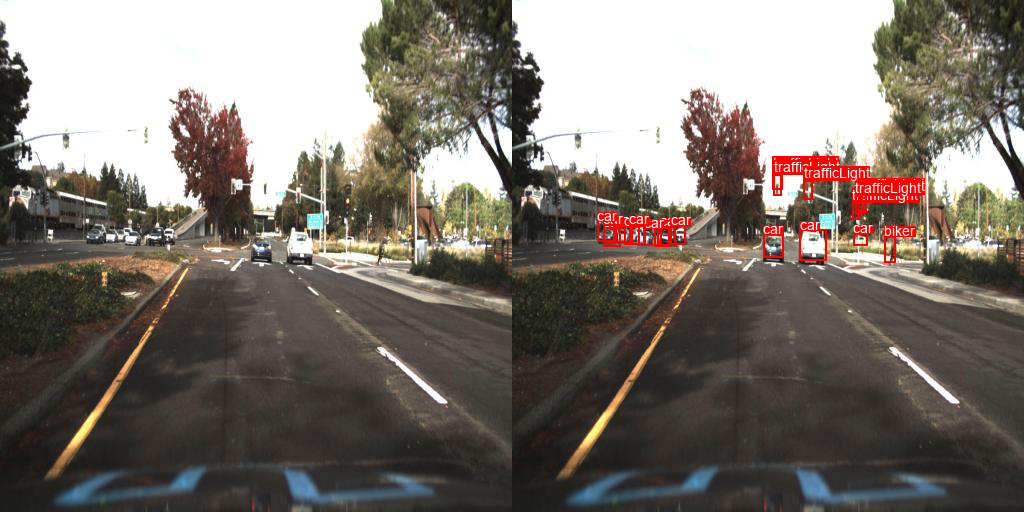

In [4]:
show_prediction_side_by_side(model=ViTmodel,
                             image_path=test_data.paths[700],
                             #image_path=r"C:\Udacity_car_data\data\test\1478020225692825294_jpg.rf.56eb69377e7d753621a360ec59206e2f.jpg",
                             pil_img=None,
                             conf_thresh=0.8)

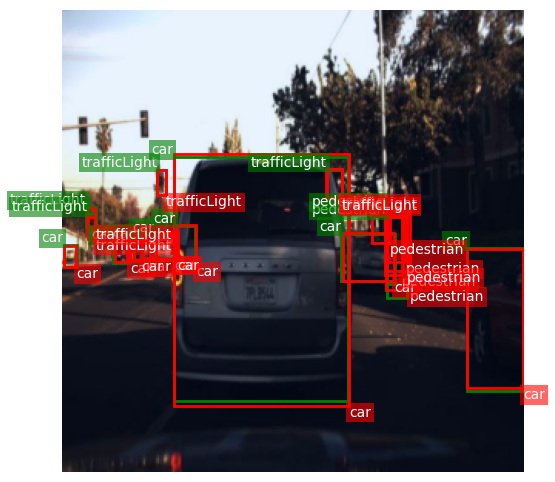

In [5]:
idx = 2000

preds = ViTmodel.predict(test_data[idx][0].unsqueeze(0).to(device='cuda'))[0]
boxes = preds["boxes"].to("cpu")    # [K,4], xyxy in 300x300 coords
labels = preds["labels"].to("cpu")  # [K]
scores = preds["scores"].to("cpu")  # [K]

keep = scores > 0.3

pred_dict = {"boxes": boxes[keep], "labels": labels[keep], "scores": scores[keep]}

test_data.show_with_box(index=idx,
                        label=True,
                        pred_dict=pred_dict,
                        pred_label=True);

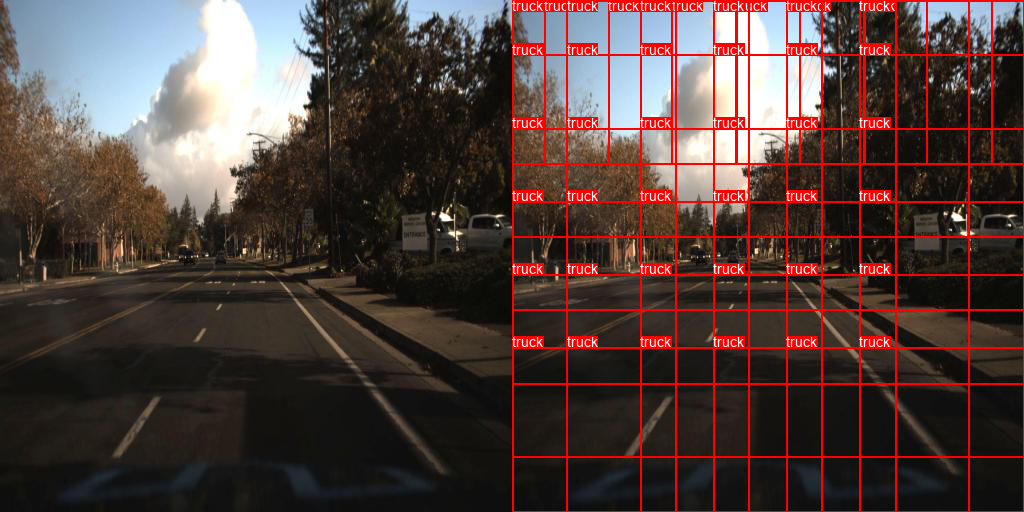

In [4]:
show_prediction_side_by_side(model=ViTmodel_no_train,
                             image_path=train_data.paths[5],
                             #image_path=r"C:\Udacity_car_data\data\test\1478020225692825294_jpg.rf.56eb69377e7d753621a360ec59206e2f.jpg",
                             pil_img=None,
                             conf_thresh=0.0)

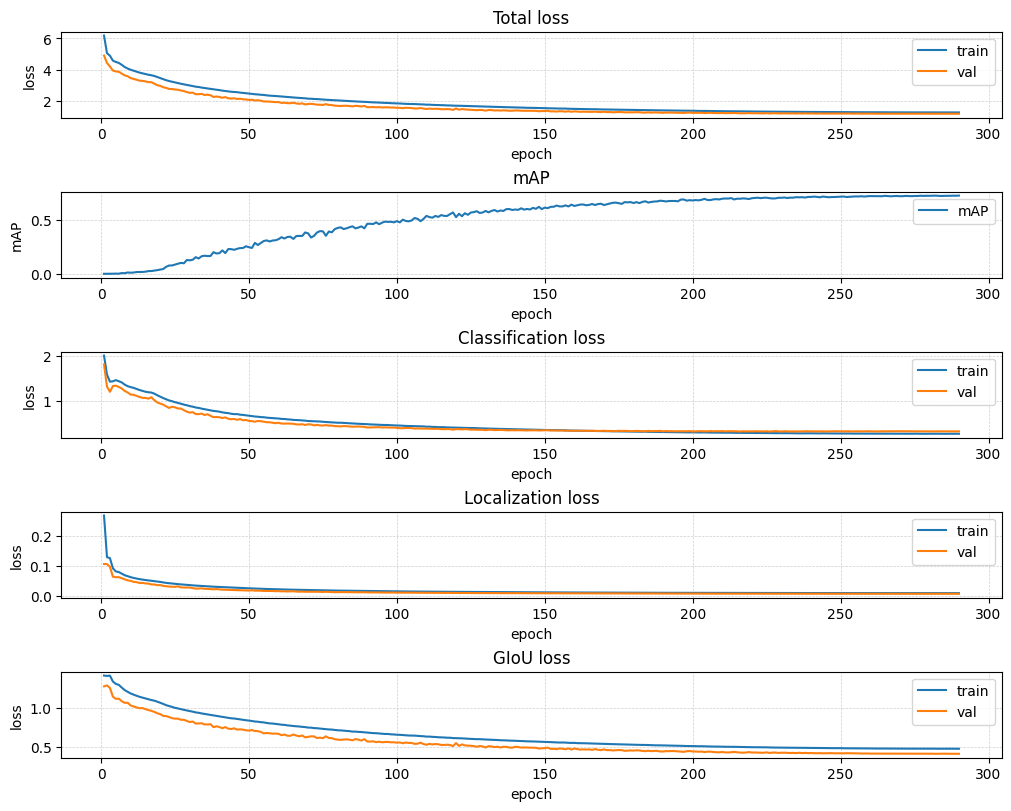

In [6]:
plot_losses(loss_dict)

In [7]:
test_tfms = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Resize((300, 300), antialias=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406],
                 std=[0.229, 0.224, 0.225]),
])

test_data = ImageClass(targ_dir=test_path, transform=test_tfms, file_pct=1, rand_seed=724, include_area=False)

import build_dataloaders_ViT

test_dataloader = DataLoader(
    test_data,
    batch_size=64,
    shuffle=False,
    num_workers=4,
    persistent_workers=True,
    prefetch_factor=2,
    pin_memory=False,
    collate_fn=build_dataloaders_ViT.collate_detection,
    multiprocessing_context="spawn",
)

map_metric = MeanAveragePrecision(box_format='xyxy', iou_type='bbox', iou_thresholds=[0.50], class_metrics=True).to(device)
map_metric.reset()

for images, targets in test_dataloader:
    preds = ViTmodel.predict(images.to(device))   # list[dict] per image
    # ensure preds/targets tensors are on `device` and labels are 0..C-1
    for i in range(len(targets)):
        for key in targets[i].keys():
            targets[i][key] = targets[i][key].to(device)
    
    map_metric.update(preds=preds, target=targets)

mAP_test_results = map_metric.compute()

mAP_test_results

{'map': tensor(0.7310),
 'map_50': tensor(0.7310),
 'map_75': tensor(-1.),
 'map_small': tensor(0.7040),
 'map_medium': tensor(0.8872),
 'map_large': tensor(0.9601),
 'mar_1': tensor(0.3525),
 'mar_10': tensor(0.8217),
 'mar_100': tensor(0.8476),
 'mar_small': tensor(0.8285),
 'mar_medium': tensor(0.9572),
 'mar_large': tensor(0.9938),
 'map_per_class': tensor([0.6407, 0.8602, 0.5129, 0.7696, 0.8717]),
 'mar_100_per_class': tensor([0.8028, 0.9310, 0.7394, 0.8423, 0.9225]),
 'classes': tensor([0, 1, 2, 3, 4], dtype=torch.int32)}

In [8]:
test_tfms = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Resize((300, 300), antialias=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406],
                 std=[0.229, 0.224, 0.225]),
])

test_data = ImageClass(targ_dir=test_path, transform=test_tfms, file_pct=1, rand_seed=724, include_area=False)

test_dataloader = DataLoader(
    test_data,
    batch_size=64,
    shuffle=False,
    num_workers=4,
    persistent_workers=True,
    prefetch_factor=2,
    pin_memory=False,
    collate_fn=build_dataloaders_ViT.collate_detection,
    multiprocessing_context="spawn",
)

map_metric = MeanAveragePrecision(box_format='xyxy', iou_type='bbox', iou_thresholds=[0.50], class_metrics=True).to(device)
map_metric.reset()

for images, targets in test_dataloader:
    preds = ViTmodel.predict(images.to(device))   # list[dict] per image
    for i in range(len(preds)):
        boxes = preds[i]["boxes"]
        labels = preds[i]["labels"]
        scores = preds[i]["scores"]

        keep = scores > 0.2

        preds[i] = {"boxes": boxes[keep], "labels": labels[keep], "scores": scores[keep]}
    # ensure preds/targets tensors are on `device` and labels are 0..C-1
    for i in range(len(targets)):
        for key in targets[i].keys():
            targets[i][key] = targets[i][key].to(device)
    
    map_metric.update(preds=preds, target=targets)

mAP_test_results = map_metric.compute()

mAP_test_results

{'map': tensor(0.7241),
 'map_50': tensor(0.7241),
 'map_75': tensor(-1.),
 'map_small': tensor(0.6973),
 'map_medium': tensor(0.8794),
 'map_large': tensor(0.9558),
 'mar_1': tensor(0.3509),
 'mar_10': tensor(0.8088),
 'mar_100': tensor(0.8283),
 'mar_small': tensor(0.8090),
 'mar_medium': tensor(0.9422),
 'mar_large': tensor(0.9821),
 'map_per_class': tensor([0.6363, 0.8486, 0.5074, 0.7651, 0.8631]),
 'mar_100_per_class': tensor([0.7838, 0.9027, 0.7151, 0.8343, 0.9056]),
 'classes': tensor([0, 1, 2, 3, 4], dtype=torch.int32)}